In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import sys

sys.path.append(r"C:\Users\bwfintech\2024\run-test")
from ml_binning_v8 import Binning
s
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.4f}'.format

In [2]:
import toad
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split
from sklearn2pmml import sklearn2pmml
import joblib
from hyperopt import hp
from hyperopt import STATUS_OK
from hyperopt import tpe
from hyperopt import fmin
from hyperopt import Trials
import matplotlib.pyplot as plt

In [3]:
def rescaling(ds, score_nm, target_nm, wt_nm, pdo, base):
    import statsmodels.api as sm
    import math
    X = ds[[score_nm]]
    Y = ds[target_nm]
    wt = ds[wt_nm].apply(lambda x: 1)
    X = sm.add_constant(X)
    glm_mdl = sm.GLM(Y, X, freq_weights = wt, family = sm.families.Binomial())
    glm_r = glm_mdl.fit()
    intercept = glm_r.params[0]
    slope = glm_r.params[1]
    intercept_std = math.log(10) - math.log(2)/pdo*base
    slope_std = math.log(2)/pdo
    return intercept, intercept_std, slope, slope_std

In [4]:
import sys
print(sys.version)

3.9.18 (main, Sep 11 2023, 14:09:26) [MSC v.1916 64 bit (AMD64)]


#### ***1. 数据导入***

In [5]:
df1 = pd.read_csv(r"D:\Data\测试样本\我来数科\宽表\建模y\复贷.csv")
print(df1.shape)
df2 = pd.read_csv(r"D:\Data\测试样本\我来数科\宽表\建模y\首贷.csv")
print(df2.shape)
df = pd.concat([df1,df2])
print(df.shape)
df.head(1)

(100000, 11)
(100274, 11)
(200274, 11)


,id,apply_date,id_no,phone,name,channel,fpd7,fpd30,mob3,dataset,month
0,170478,2024-07-26,e39a00cc167f78a246ad188ced0ce491af373b7280dbca...,eeb56a019ad78fd9f6d3465cb9cd6e264a44a3dc5ed869...,b1306624589ee0de931ff84364e7aac7b7a2b047c3a324...,复贷,0.0000,0.0000,0.0000,train,2024-07


In [6]:
df_bd = pd.read_csv(r"D:\Data\测试样本\我来数科\宽表\yd.csv")
print(df_bd.shape)
df_bd[:1]

(239654, 308)


,id_no,phone,apply_date,S02_n82,S02_n5,S02_n55,S03_n56,S02_n48,S04_n18,S03_n80,...,S01_n21,S04_n33,S06_n5,S02_n27,S03_n49,S03_n60,S05_n4,S05_n2,S02_n69,S06_n4
0,11773b580c48b87dc8b680c0099e0fb3099d448b0831e7...,95cd6319debd52dfe4026ce83ed6ce74f77d1a21cb9c21...,2025-03-25,NaN,0.2807,0.1674,0.5845,0.3875,0.0000,0.5459,...,0.3843,0.1000,0.0014,0.0000,0.6859,0.6444,0.0421,0.1743,0.0497,0.0000


In [7]:
df = pd.merge(df, df_bd)
print(df.shape)
df.head(1)

(200274, 316)


,id,apply_date,id_no,phone,name,channel,fpd7,fpd30,mob3,dataset,...,S01_n21,S04_n33,S06_n5,S02_n27,S03_n49,S03_n60,S05_n4,S05_n2,S02_n69,S06_n4
0,170478,2024-07-26,e39a00cc167f78a246ad188ced0ce491af373b7280dbca...,eeb56a019ad78fd9f6d3465cb9cd6e264a44a3dc5ed869...,b1306624589ee0de931ff84364e7aac7b7a2b047c3a324...,复贷,0.0000,0.0000,0.0000,train,...,0.3301,0.0000,NaN,NaN,0.6667,0.7284,0.0645,0.1755,NaN,NaN


In [8]:
df.info(max_cols=2000)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200274 entries, 0 to 200273
Data columns (total 316 columns):
 #    Column      Non-Null Count   Dtype  
---   ------      --------------   -----  
 0    id          200274 non-null  int64  
 1    apply_date  200274 non-null  object 
 2    id_no       200274 non-null  object 
 3    phone       200274 non-null  object 
 4    name        200274 non-null  object 
 5    channel     200274 non-null  object 
 6    fpd7        200000 non-null  float64
 7    fpd30       179187 non-null  float64
 8    mob3        153258 non-null  float64
 9    dataset     200274 non-null  object 
 10   month       200274 non-null  object 
 11   S02_n82     6076 non-null    float64
 12   S02_n5      107654 non-null  float64
 13   S02_n55     3209 non-null    float64
 14   S03_n56     199174 non-null  float64
 15   S02_n48     135430 non-null  float64
 16   S04_n18     124409 non-null  float64
 17   S03_n80     199175 non-null  float64
 18   S02_n57     1145 non-n

In [9]:
key_col = ['id_no','phone','apply_date','channel','fpd7','fpd30','mob3','dataset','month','sampleWeight']

In [10]:
col = df.columns[11:].tolist()
col

['S02_n82',
 'S02_n5',
 'S02_n55',
 'S03_n56',
 'S02_n48',
 'S04_n18',
 'S03_n80',
 'S02_n57',
 'S02_n62',
 'S01_n27',
 'S02_n54',
 'S03_n27',
 'S03_n70',
 'S03_n39',
 'S03_n47',
 'S02_n86',
 'S02_n44',
 'S03_n100',
 'S02_n88',
 'S04_n14',
 'S02_n79',
 'S06_n27',
 'S03_n13',
 'S02_n61',
 'S03_n36',
 'S02_n78',
 'S06_n9',
 'S03_n6',
 'S03_n31',
 'S03_n38',
 'S03_n69',
 'S06_n14',
 'S02_n85',
 'S04_n28',
 'S02_n41',
 'S03_n52',
 'S01_n25',
 'S06_n2',
 'S06_n22',
 'S02_n64',
 'S01_n4',
 'S02_n76',
 'S01_n12',
 'S06_n17',
 'S02_n13',
 'S03_n5',
 'S05_n6',
 'S03_n25',
 'S05_n5',
 'S03_n23',
 'S03_n65',
 'S03_n14',
 'S03_n21',
 'S02_n12',
 'S02_n77',
 'S06_n20',
 'S02_n4',
 'S04_n11',
 'S03_n101',
 'S04_n27',
 'S03_n10',
 'S02_n47',
 'S05_n7',
 'S03_n73',
 'S03_n81',
 'S03_n102',
 'S06_n19',
 'S05_n11',
 'S03_n44',
 'S02_n66',
 'S01_n24',
 'S03_n34',
 'S02_n29',
 'S02_n30',
 'S06_n21',
 'S03_n3',
 'S03_n1',
 'S02_n15',
 'S01_n30',
 'S03_n93',
 'S02_n65',
 'S03_n28',
 'S02_n9',
 'S03_n19',
 '

#### ***2. 样本划分，特征筛选***

In [11]:
ds_raw = df.copy()

# ds_raw = df[df['channel'] == 'A'].reset_index(drop = True)
ds_raw['sampleWeight'] = 1

print(ds_raw.shape)
ds_raw.head(1)

(200274, 317)


,id,apply_date,id_no,phone,name,channel,fpd7,fpd30,mob3,dataset,...,S04_n33,S06_n5,S02_n27,S03_n49,S03_n60,S05_n4,S05_n2,S02_n69,S06_n4,sampleWeight
0,170478,2024-07-26,e39a00cc167f78a246ad188ced0ce491af373b7280dbca...,eeb56a019ad78fd9f6d3465cb9cd6e264a44a3dc5ed869...,b1306624589ee0de931ff84364e7aac7b7a2b047c3a324...,复贷,0.0000,0.0000,0.0000,train,...,0.0000,NaN,NaN,0.6667,0.7284,0.0645,0.1755,NaN,NaN,1


In [12]:
ds_raw[ds_raw['fpd7'].isin([0,1])].groupby(['dataset'])['fpd7'].value_counts(dropna = False, normalize = True).unstack()

fpd7,0.0000,1.0000
dataset,,
oot,0.9775,0.0225
test,0.9757,0.0243
train,0.9755,0.0245


In [13]:
ds_raw[ds_raw['fpd30'].isin([0,1])].groupby(['dataset'])['fpd30'].value_counts(dropna = False, normalize = True).unstack()

fpd30,0.0000,1.0000
dataset,,
oot,0.9812,0.0188
test,0.9801,0.0199
train,0.9802,0.0198


In [14]:
ds_raw[ds_raw['mob3'].isin([0,1])].groupby(['dataset'])['mob3'].value_counts(dropna = False, normalize = True).unstack()

mob3,0.0000,1.0000
dataset,,
oot,0.9487,0.0513
test,0.9453,0.0547
train,0.9453,0.0547


In [15]:
fea_psi = pd.read_excel(r"D:\Data\测试样本\我来数科\建模文件\数据质检\数据报告.xlsx",sheet_name='区分渠道&时间PSI')
print(fea_psi.shape)
# fea_psi = fea_psi[fea_psi['渠道']==2]
print(fea_psi.shape)
fea_psi = fea_psi[fea_psi['基准样本量']>1000]
fea_psi = fea_psi[fea_psi['对照样本量']>1000]
fea_psi = fea_psi[fea_psi['PSI']>=0.15]
print(fea_psi.shape)
fea_psi = fea_psi['特征'].unique().tolist()
fea_psi

(88392, 7)
(88392, 7)
(200, 7)


['apply_date2',
 'sc0037',
 'sc0470',
 'sc0885',
 'feat39601',
 'feat39611',
 'feat39612',
 '最早一次查询距今的天数',
 '最早一次在非银机构距今的天数',
 'S04_n23',
 'S04_n9',
 'S04_n4',
 'feat1161',
 'feat42988',
 '60天总申请白天次数',
 'f27',
 'f34',
 'f49',
 'feat25532',
 'f44',
 'feat39726',
 'S03_n34',
 'S03_n29',
 'feat39592',
 'feat15778',
 'feat51487',
 'hds_month_cnt_from_most_early_purchase_time',
 'f28',
 'feat1163',
 'feat40430',
 'feat27877',
 'S03_n50',
 'S03_n83',
 'feat39625',
 'S03_n31',
 '30天相对过去720天新增总平台数',
 'S03_n79',
 'S03_n72',
 'S03_n71',
 'feat39591',
 'sc0107',
 'sc0871',
 'sc0883',
 'sc0884']

In [16]:
fea_iv = pd.read_excel(r"D:\Data\测试样本\我来数科\建模文件\数据质检\数据报告.xlsx",sheet_name='flag2_渠道&时序的区分度')
print(fea_iv.shape)
fea_iv1 = fea_iv[fea_iv['渠道']==1]
print(fea_iv1.shape)
# fea_iv = fea_iv[fea_iv['时间'].isin(['[\'2024-04\']','[\'2024-05\']','[\'2024-06\']'])]
# print(fea_iv.shape)
has_both = fea_iv1.groupby(['特征'])['trend'].apply(lambda x : 
                                                {'increasing','decreasing'}.issubset(set(x)))
fea_iv1 = has_both[has_both].index.tolist()

fea_iv2 = fea_iv[fea_iv['渠道']==2]
print(fea_iv2.shape)
# fea_iv = fea_iv[fea_iv['时间'].isin(['[\'2024-04\']','[\'2024-05\']','[\'2024-06\']'])]
# print(fea_iv.shape)
has_both = fea_iv2.groupby(['特征'])['trend'].apply(lambda x : 
                                                {'increasing','decreasing'}.issubset(set(x)))
fea_iv2 = has_both[has_both].index.tolist()
fea_iv = fea_iv1+fea_iv2

fea_iv

(54846, 8)
(27423, 8)
(27423, 8)


['12个月内申请人逾期银行次数(171051)',
 '15天内其他申请平台数',
 '15天总申请夜晚平台数',
 '15天总申请夜晚次数',
 '1年以前申请人逾期互联网金融次数(171067)',
 '1年以前申请人逾期其他平台次数(171060)',
 '1年以前申请人逾期持牌消金次数(171066)',
 '1年以前申请人逾期银行次数(171061)',
 '3个月申请人逾期其他平台次数(171030)',
 '60天内其他申请次数',
 '6个月内申请人逾期其他平台数(170040)',
 '7天内其他申请次数',
 'F10',
 'F127',
 'F15',
 'F32',
 'F39',
 'F72',
 'F85',
 'F93',
 'S02_n20',
 'S02_n21',
 'S02_n29',
 'S02_n3',
 'S02_n30',
 'S02_n33',
 'S02_n35',
 'S02_n46',
 'S02_n50',
 'S02_n51',
 'S02_n52',
 'S02_n57',
 'S02_n61',
 'S02_n67',
 'S02_n81',
 'S02_n86',
 'S03_n12',
 'S03_n6',
 'S04_n10',
 'S04_n8',
 'S05_n11',
 'S06_n10',
 'S06_n2',
 'S06_n21',
 'S06_n23',
 'S06_n24',
 'S06_n26',
 'S06_n27',
 'S06_n28',
 'S06_n29',
 'S06_n30',
 'S06_n32',
 'S06_n35',
 'S06_n5',
 'S06_n6',
 'S06_n8',
 'S06_n9',
 'activite_months_count',
 'actual_order_count_ratio',
 'applyAmountIntervalRecent30',
 'applyCountRecent7',
 'assgro_invest_latest_avg',
 'assgro_invest_latest_max',
 'avgFund',
 'busLevel',
 'caregory_most_freq_item_count_180d_cu

In [17]:
col = [x for x in col if x not in fea_psi and x not in fea_iv]
len(col)

247

In [18]:
# col.remove(' 疑似准入风险V1（31006）')
# len(col)

In [19]:
y = 'fpd30'

In [20]:
ds_raw = ds_raw[key_col + col]
print(ds_raw.shape)
ds_raw = ds_raw[ds_raw[y].isin([0,1])]
print(ds_raw.shape)
ds_raw[:1]

(200274, 257)
(177474, 257)


,id_no,phone,apply_date,channel,fpd7,fpd30,mob3,dataset,month,sampleWeight,...,S02_n19,S02_n34,S01_n21,S04_n33,S03_n49,S03_n60,S05_n4,S05_n2,S02_n69,S06_n4
0,e39a00cc167f78a246ad188ced0ce491af373b7280dbca...,eeb56a019ad78fd9f6d3465cb9cd6e264a44a3dc5ed869...,2024-07-26,复贷,0.0000,0.0000,0.0000,train,2024-07,1,...,NaN,NaN,0.3301,0.0000,0.6667,0.7284,0.0645,0.1755,NaN,NaN


In [21]:
X_train = ds_raw[ds_raw['dataset'] == 'train'][col]
X_test = ds_raw[ds_raw['dataset'] == 'test'][col]
X_oot = ds_raw[ds_raw['dataset'] == 'oot'][col]

y_train = ds_raw[ds_raw['dataset'] == 'train'][y]
y_test = ds_raw[ds_raw['dataset'] == 'test'][y]
y_oot = ds_raw[ds_raw['dataset'] == 'oot'][y]

Tr_weight = ds_raw[ds_raw['dataset'] == 'train']['sampleWeight']
Ts_weight = ds_raw[ds_raw['dataset'] == 'test']['sampleWeight']
oot_weight = ds_raw[ds_raw['dataset'] == 'oot']['sampleWeight']

In [22]:
catvar_lst = X_train.select_dtypes('object').columns.tolist()
for i in catvar_lst:
    X_train[i] = X_train[i].astype('category')
    X_test[i] = X_test[i].astype('category')
    X_oot[i] = X_oot[i].astype('category')

In [23]:
y_train.value_counts(normalize = True)

fpd30
0.0000   0.9802
1.0000   0.0198
Name: proportion, dtype: float64

In [24]:
y_test.value_counts(normalize = True)

fpd30
0.0000   0.9801
1.0000   0.0199
Name: proportion, dtype: float64

In [25]:
y_oot.value_counts(normalize = True)

fpd30
0.0000   0.9812
1.0000   0.0188
Name: proportion, dtype: float64

In [26]:
train_set = lgb.Dataset(X_train, y_train, categorical_feature = catvar_lst, weight = Tr_weight, free_raw_data=False)
test_set = lgb.Dataset(X_test, y_test, categorical_feature = catvar_lst, weight = Ts_weight, free_raw_data=False)
oot_set = lgb.Dataset(X_oot, y_oot, categorical_feature = catvar_lst, weight = oot_weight, free_raw_data=False)

#### ***3. 模型训练***

In [27]:
# 定义超参数范围
space = {'boosting_type': 'gbdt',
         'objective': 'binary',
         'metric':'auc',
         'is_unbalance': True,   ###自动处理不平衡的类别，通过调整样本权重来优化少数类的性能
         'feature_pre_filter': True,   ###可预先过滤特征以减少计算量
         'nthread': -1,   ###线程数
         'verbose': -1,   ###输出
         'bagging_freq': 2,   ###每多少轮进行一次bagging，可减少模型过拟合
         'bagging_fraction': hp.quniform("bagging_fraction", 0.5, 0.8, 0.1),   ###每次bagging中随机选择的数据比例，可以增加模型的泛化能力
         'feature_fraction': hp.quniform("feature_fraction", 0.5, 0.8, 0.1),   ###每次迭代中随机选择参与构建树的特征比例，有助于防止过拟合
         'max_depth': hp.quniform('max_depth', 2, 4, 1),   ###树深，越大越容易过拟合
         'num_leaves': hp.quniform('num_leaves', 2, 50, 2),   ###叶子节点数
         'n_estimators': hp.quniform('n_estimators', 300, 500, 10),   ###要构建的树的数量
         'learning_rate': hp.uniform('learning_rate', 0.005, 0.02),   ###学习率
         'lambda_l1': hp.randint('lambda_l1',10, 50),   ###L1正则化项的系数
         'lambda_l2': hp.randint('lambda_l2',10, 50),   ###L2正则化项的系数
         'min_data_in_leaf': hp.quniform('min_data_in_leaf', int(X_train.shape[0]*0.01), int(X_train.shape[0]*0.05), 100)   ###叶子节点上的最少样本数
        }

In [28]:
####定义最小化目标函数
from sklearn.model_selection import cross_val_score

def objective(params):
    
    for key in ["max_depth", "num_leaves", "n_estimators", "min_data_in_leaf"]:
        params[key] = int(params[key])
    for key in ["feature_fraction", "bagging_fraction"]:
        params[key] = round(params[key], 1)
        

    model = lgb.train(params, train_set, valid_sets = test_set)

    
    
    tr_prob = model.predict(X_train, num_iteration = model.best_iteration)
    tr_auc = roc_auc_score(y_train, tr_prob,sample_weight=Tr_weight)
    ts_prob = model.predict(X_test, num_iteration = model.best_iteration)
    ts_auc = roc_auc_score(y_test, ts_prob,sample_weight=Ts_weight)
    oot_prob = model.predict(X_oot, num_iteration = model.best_iteration)
    oot_auc = roc_auc_score(y_oot, oot_prob,sample_weight=oot_weight)


    loss = -oot_auc + np.abs(tr_auc - ts_auc)
    
#     loss = -(oot_auc - 0.5 *np.log (tr_auc/oot_auc))

    
    
    print("train_AUC:{}, test_AUC:{}, oot_AUC:{}, 参数:{}".format(tr_auc, ts_auc,oot_auc, params), '\n')
    return {'loss': loss, 'params': params, 'status': STATUS_OK}

In [ ]:
best_params = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 150, verbose = True)
print("最优参数", best_params)

In [ ]:
best_params

In [ ]:
# 最优参数配置
params_best = {'boosting_type': 'gbdt',
               'objective': 'binary',
               'metric':'auc',
               'is_unbalance': True,
               'feature_pre_filter': True,
               'nthread': -1,
               'verbose': -1,
               'bagging_freq': 2,
               'feature_fraction': round(best_params['feature_fraction'], 1),
               'bagging_fraction': round(best_params['bagging_fraction'], 1),
               'max_depth': int(best_params['max_depth']),
               'num_leaves': int(best_params['num_leaves']),
               'n_estimators': int(best_params['n_estimators']),
               'learning_rate': best_params['learning_rate'],
               'lambda_l1': int(best_params['lambda_l1']),
               'lambda_l2': int(best_params['lambda_l2']),
               'min_data_in_leaf': int(best_params['min_data_in_leaf'])
              }

In [ ]:
# model = lgb.train(params_best, train_set, num_boost_round = 200)
model = lgb.train(params_best, train_set, valid_sets = test_set)

In [ ]:
# 模型评估
y_prob = model.predict(X_train, num_iteration=model.best_iteration)
auc_score = roc_auc_score(y_train, y_prob)
fpr, tpr, thod = roc_curve(y_train, y_prob)
KS = max(abs(fpr - tpr))
print('训练集AUC:{}, KS:{}'.format(auc_score,KS))

In [ ]:
# 模型评估
y_prob = model.predict(X_train, num_iteration=model.best_iteration)
auc_score = roc_auc_score(y_train, y_prob, sample_weight = Tr_weight)
fpr, tpr, thod = roc_curve(y_train, y_prob, sample_weight = Tr_weight)
KS = max(abs(fpr - tpr))
print('训练集AUC:{}, KS:{}'.format(auc_score,KS))

In [ ]:
y_prob = model.predict(X_test, num_iteration=model.best_iteration)
auc_score = roc_auc_score(y_test, y_prob, sample_weight = Ts_weight)
fpr, tpr, thod = roc_curve(y_test, y_prob, sample_weight = Ts_weight)
KS = max(abs(fpr - tpr))
print('测试集AUC:{}, KS:{}'.format(auc_score, KS))

In [ ]:
y_prob = model.predict(X_oot, num_iteration=model.best_iteration)
auc_score = roc_auc_score(y_oot, y_prob, sample_weight = oot_weight)
fpr, tpr, thod = roc_curve(y_oot, y_prob, sample_weight = oot_weight)
KS = max(abs(fpr - tpr))
print('验证集AUC:{}, KS:{}'.format(auc_score, KS))

In [ ]:
model.feature_name()

In [ ]:
best_params

In [ ]:
plt.rcParams["figure.figsize"]=(8,30)
lgb.plot_importance(model, importance_type = 'split')

In [ ]:
feat_imp = pd.DataFrame(sorted(zip(model.feature_importance(), model.feature_name()), reverse = True))
feat_imp.columns = ['importance', 'feature']
feat_imp[['feature', 'importance']]

In [ ]:
####剔除重要性低的特征
feat_select = feat_imp[feat_imp.importance > 0]['feature'].tolist()
print(len(feat_select))

In [ ]:
feat_select

In [ ]:
X_train = X_train[feat_select]
train_set = lgb.Dataset(X_train, y_train, categorical_feature = [x for x in catvar_lst if x in X_train.columns],
                        weight = Tr_weight, free_raw_data=False)

X_test = X_test[feat_select]
test_set = lgb.Dataset(X_test, y_test, categorical_feature = [x for x in catvar_lst if x in X_train.columns],
                       weight = Ts_weight, free_raw_data=False)

X_oot = X_oot[feat_select]

In [ ]:
# 定义超参数范围
space = {'boosting_type': 'gbdt',
         'objective': 'binary',
         'metric':'auc',
         'is_unbalance': True,   ###自动处理不平衡的类别，通过调整样本权重来优化少数类的性能
         'feature_pre_filter': False,   ###可预先过滤特征以减少计算量
         'nthread': -1,   ###线程数
         'verbose': -1,   ###输出
         'bagging_freq': 2,   ###每多少轮进行一次bagging，可减少模型过拟合
         'bagging_fraction': hp.quniform("bagging_fraction", 0.6, 0.8, 0.1),   ###每次bagging中随机选择的数据比例，可以增加模型的泛化能力
         'feature_fraction': hp.quniform("feature_fraction", 0.6, 0.8, 0.1),   ###每次迭代中随机选择参与构建树的特征比例，有助于防止过拟合
         'max_depth': hp.quniform('max_depth', 2, 4, 1),   ###树深，越大越容易过拟合
         'num_leaves': hp.quniform('num_leaves', 2, 50, 2),   ###叶子节点数
         'n_estimators': hp.quniform('n_estimators', 200, 400, 10),   ###要构建的树的数量
         'learning_rate': hp.uniform('learning_rate', 0.005, 0.02),   ###学习率
         'lambda_l1': hp.randint('lambda_l1',10, 50),   ###L1正则化项的系数
         'lambda_l2': hp.randint('lambda_l2',10, 50),   ###L2正则化项的系数
         'min_data_in_leaf': hp.quniform('min_data_in_leaf', int(X_train.shape[0]*0.01), int(X_train.shape[0]*0.05), 100)   ###叶子节点上的最少样本数
        }

In [ ]:
best_params = fmin(fn = objective, space = space, algo = tpe.suggest, max_evals = 150, verbose = True)
print("最优参数", best_params)

In [ ]:
# 最优参数配置
params_best = {'boosting_type': 'gbdt',
               'objective': 'binary',
               'metric':'auc',
               'is_unbalance': True,
               'feature_pre_filter': False,
               'nthread': -1,
               'verbose': -1,
               'bagging_freq': 2,
               'feature_fraction': round(best_params['feature_fraction'], 1),
               'bagging_fraction': round(best_params['bagging_fraction'], 1),
               'max_depth': int(best_params['max_depth']),
               'num_leaves': int(best_params['num_leaves']),
               'n_estimators': int(best_params['n_estimators']),
               'learning_rate': best_params['learning_rate'],
               'lambda_l1': int(best_params['lambda_l1']),
               'lambda_l2': int(best_params['lambda_l2']),
               'min_data_in_leaf': int(best_params['min_data_in_leaf'])
              }

In [ ]:
# model2 = lgb.train(params_best, train_set, num_boost_round = 200)
model2 = lgb.train(params_best, train_set, valid_sets = test_set, 
                  num_boost_round = 200)

In [ ]:
# 模型评估
tr_prob = model2.predict(X_train, num_iteration = model2.best_iteration)
auc_score = roc_auc_score(y_train, tr_prob, sample_weight = Tr_weight)
fpr, tpr, thod = roc_curve(y_train, tr_prob, sample_weight = Tr_weight)
KS = max(abs(fpr - tpr))
print('训练集AUC:{}, KS:{}'.format(auc_score,KS))

In [ ]:
ts_prob = model2.predict(X_test[feat_select], num_iteration = model2.best_iteration)
auc_score = roc_auc_score(y_test, ts_prob, sample_weight = Ts_weight)
fpr, tpr, thod = roc_curve(y_test, ts_prob, sample_weight = Ts_weight)
KS = max(abs(fpr - tpr))
print('测试集AUC:{}, KS:{}'.format(auc_score, KS))

In [ ]:
oot_prob = model2.predict(X_oot[feat_select], num_iteration = model2.best_iteration)
auc_score = roc_auc_score(y_oot, oot_prob, sample_weight = oot_weight)
fpr, tpr, thod = roc_curve(y_oot, oot_prob, sample_weight = oot_weight)
KS = max(abs(fpr - tpr))
print('验证集AUC:{}, KS:{}'.format(auc_score, KS))

In [51]:
import hundredim.util.patternAwareScorecardModule as PASM

ds_raw['score'] = model2.predict(ds_raw[feat_select], num_iteration = model2.best_iteration)
perf_out = PASM.performance_calc(ds_raw, scores_ls = ['score'],
                                 targets_ls = [y], byVars_ls = ['channel','dataset'], weight = 'sampleWeight', digits = 4, sv = [])
perf_out['KS_summary'][['channel','dataset', 'score', 'KS']].set_index(['channel','dataset', 'score']).unstack('score').sort_index(ascending = False).to_clipboard(excel=True)
perf_out['KS_summary'][['channel','dataset', 'score', 'KS']].set_index(['channel','dataset', 'score']).unstack('score').sort_index(ascending = False)

KS
score            score
channel dataset       
首贷      train   0.2370
        test    0.1952
        oot     0.2176
复贷      train   0.2339
        test    0.2167
        oot     0.2319

In [52]:
import hundredim.util.patternAwareScorecardModule as PASM

ds_raw['score'] = model2.predict(ds_raw[feat_select], num_iteration = model2.best_iteration)
perf_out = PASM.performance_calc(ds_raw, scores_ls = ['score'],
                                 targets_ls = [y], byVars_ls = ['channel','month'], weight = 'sampleWeight', digits = 4, sv = [])
perf_out['KS_summary'][['channel','month', 'score', 'KS']].set_index(['channel','month', 'score']).to_clipboard(excel=True)
perf_out['KS_summary'][['channel','month', 'score', 'KS']].set_index(['channel','month', 'score'])

KS
channel month   score       
复贷      2024-07 score 0.2522
        2024-08 score 0.2302
        2024-09 score 0.2308
        2024-10 score 0.2266
        2024-11 score 0.2483
        2024-12 score 0.2514
        2025-01 score 0.2552
        2025-02 score 0.2298
        2025-03 score 0.2770
首贷      2024-07 score 0.2410
        2024-08 score 0.2337
        2024-09 score 0.2572
        2024-10 score 0.2154
        2024-11 score 0.2236
        2024-12 score 0.2263
        2025-01 score 0.3006
        2025-02 score 0.2228
        2025-03 score 0.1941

In [53]:
import os
# 模型保存
joblib.dump(model2, rf"D:\Data\测试样本\我来数科\建模文件\模型文件\lgb\整体\yd_{y}.pkl")
os.chdir(rf"D:\Data\测试样本\我来数科\建模文件\模型文件\lgb\整体")  # 绝对路径示例
model2.save_model(f"yd_{y}.model", num_iteration = model.best_iteration)

<Axes: >

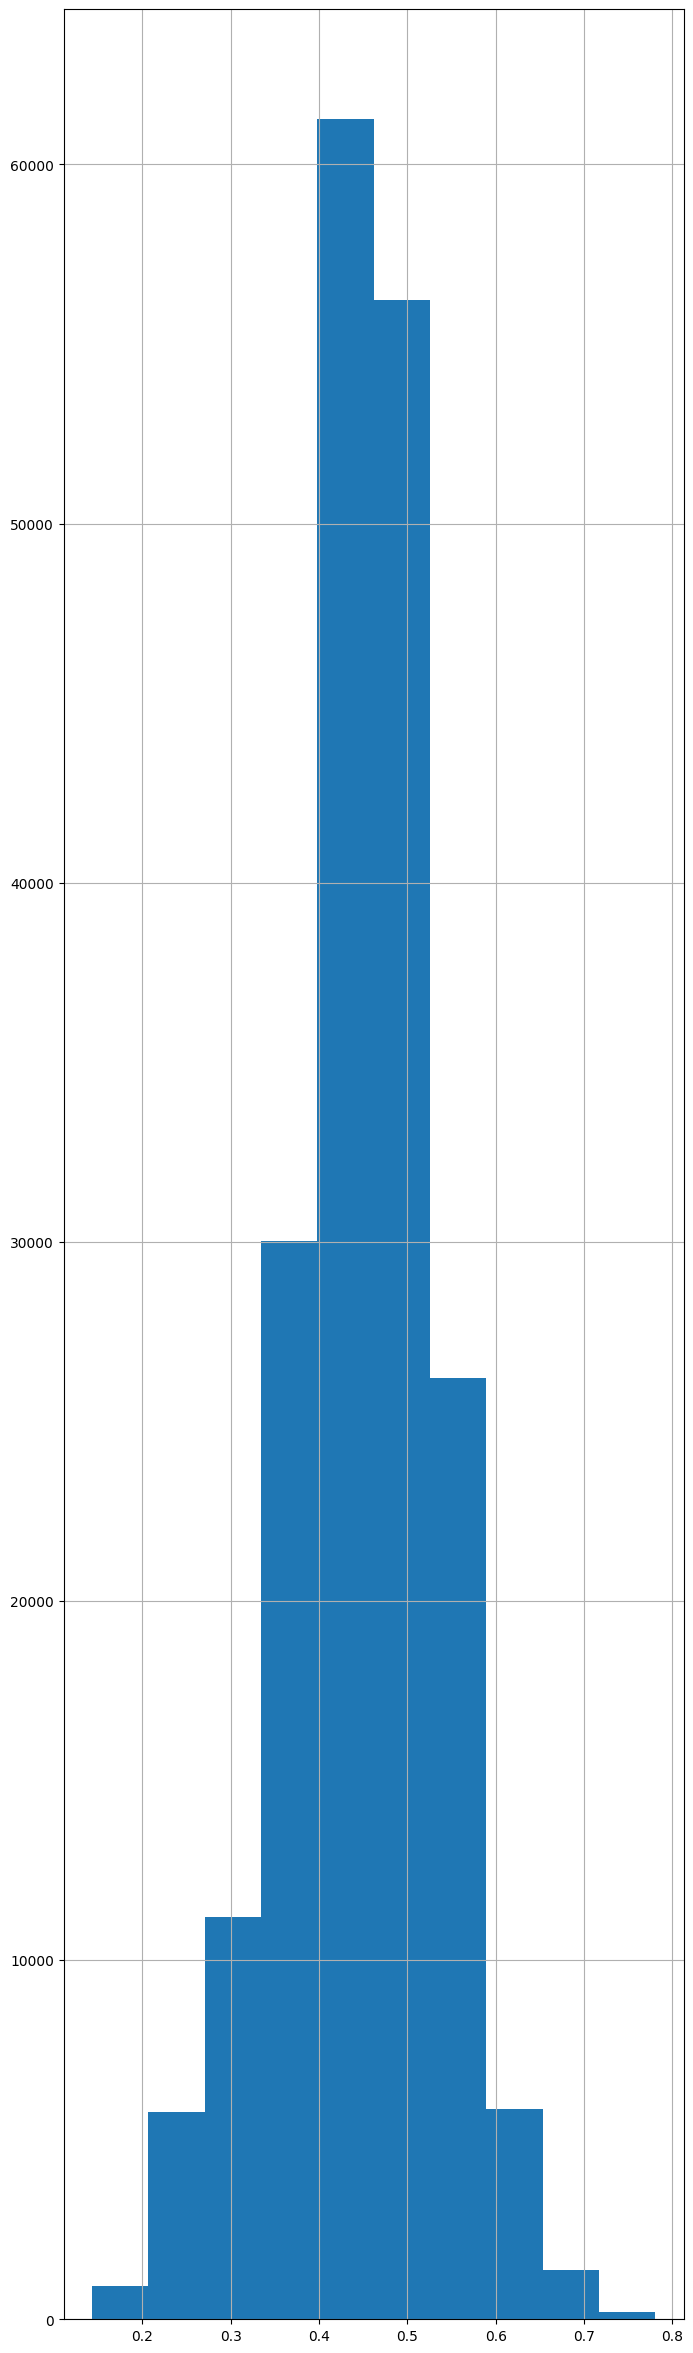

In [54]:
ds_raw['score'].hist()

##### 入模参数以及入模特征

In [ ]:
model2.params

In [ ]:
feat_imp2 = pd.DataFrame(sorted(zip(model2.feature_importance(), model2.feature_name()), reverse = True))
feat_imp2.columns = ['importance', 'feature']
feat_imp2[['feature', 'importance']]

In [ ]:
ds_raw.groupby(['channel'])['score'].hist(bins=100)

##### ***可视化***

In [ ]:
plt.rcParams["figure.figsize"]=(4,3)
def plt_show(y, score):
    from sklearn.metrics import roc_curve, auc
    fpr,tpr,threshold=roc_curve(y, score)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area=%0.3f)'%roc_auc)
    plt.plot([0,1],[0,1],color='navy',linestyle='--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC_curve')
    plt.legend(loc="lower right")
    return plt.show(), print('KS:',max(tpr-fpr))

In [ ]:
plt_show(y_train, tr_prob)

In [ ]:
plt_show(y_test, ts_prob)

In [ ]:
plt_show(y_oot, oot_prob)

##### ***排序性***

In [ ]:
pred_dr = pd.DataFrame(model2.predict(X_train), columns = ['scores'])
pred_dr['gbflag'] = (1 - y_train).reset_index(drop = True)
Bin_tr = Binning(pred_dr, bin_num = 10)
Bin_tr.binning_num('scores')

In [ ]:
pred_ts = pd.DataFrame(model2.predict(X_test[model2.feature_name()]), columns = ['scores'])
pred_ts['gbflag'] = (1 - y_test).reset_index(drop = True)
Bin_ts = Binning(pred_ts, bin_num = 10)
Bin_ts.binning_num('scores')

In [ ]:
pred_oot = pd.DataFrame(model2.predict(X_oot[model2.feature_name()]), columns = ['scores'])
pred_oot['gbflag'] = (1 - y_oot).reset_index(drop = True)
Bin_oot = Binning(pred_oot, bin_num = 10)
Bin_oot.binning_num('scores')

#### ***4. 子分快速融合***

In [ ]:
df_all = ds_raw.copy()
for i in catvar_lst:
    df_all[i] = df_all[i].astype('category')
df_all['score'] = model2.predict(df_all[feat_select], num_iteration = model2.best_iteration)

In [ ]:
df_out = df.copy()
df_out['score'] = model2.predict(df_out[feat_select], num_iteration = model2.best_iteration)

In [ ]:
res_col = ['SCORE1', 'SCORE2', 'SCORE3', 'score']
for i in res_col:
    intercept, intercept_std, slope, slope_std = rescaling(ds = df_all, score_nm = i, target_nm = 'mob3', wt_nm = 'sampleWeight',
                                                           pdo = 150, base = 350)
    A = (intercept - intercept_std)/slope_std
    B = slope/slope_std
    df_all[i + '_res'] = (A + B*df_all[i]).round(4)
    df_out[i + '_res'] = (A + B*df_out[i]).round(4)
    print(i, A, B)
    print(df_all[i + '_res'].min(), df_all[i + '_res'].max(), '\n')

In [ ]:
####逐步回归
train_data = toad.selection.stepwise(df_all[df_all.index.isin(X_train.index)][[x for x in df_all.columns if '_res' in x] + ['mob3']],
                                     target = 'mob3', estimator='ols', direction = 'both', criterion = 'aic')
col = list(train_data.drop(['mob3'],axis=1).columns)
print(len(col))
col

In [ ]:
train_data[col].corr(method = 'spearman')

In [ ]:
test_data = df_all[df_all.index.isin(X_test.index)]
oot_data = df_all[df_all.index.isin(X_oot.index)]

In [ ]:
from toad.metrics import KS, AUC
####逻辑回归训练
lr = LogisticRegression()
lr.fit(train_data[col], train_data['mob3'])

# 预测训练集和测试集上的结果
pred_train = lr.predict_proba(train_data[col])[:,1]
pred_test = lr.predict_proba(test_data[col])[:,1]
pred_oot = lr.predict_proba(oot_data[col])[:,1]

print('train KS',KS(pred_train, train_data['mob3']))
print('train AUC',AUC(pred_train, train_data['mob3']),'\n')

print('ts KS',KS(pred_test, test_data['mob3']))
print('ts AUC',AUC(pred_test, test_data['mob3']),'\n')

print('OOT KS',KS(pred_oot, oot_data['mob3']))
print('OOT AUC',AUC(pred_oot, oot_data['mob3']))

In [ ]:
lr.feature_names_in_

In [ ]:
lr.coef_

In [ ]:
lr.intercept_

In [ ]:
train_data['dataset'] = 'train'
test_data['dataset'] = 'test'
oot_data['dataset'] = 'oot'
pred_df = pd.concat([train_data['dataset'], test_data['dataset'], oot_data['dataset']], axis = 0)
pred_df = pd.merge(df_all, pred_df, left_index = True, right_index = True)
pred_df['score'] = model2.predict(pred_df[feat_select], num_iteration = model2.best_iteration)
pred_df['scores'] = lr.predict_proba(pred_df[col])[:,1]

In [ ]:
pred_df['gbflag'] = 1 - pred_df['mob3']
Bin_df = Binning(pred_df[pred_df['dataset'] == 'oot'], bin_num = 10)
Bin_df.binning_num('scores')

In [ ]:
pred_df['gbflag'] = 1 - pred_df['fpd30']
Bin_df = Binning(pred_df[pred_df['dataset'] == 'oot'], bin_num = 10)
Bin_df.binning_num('scores')

In [ ]:
pred_df.groupby(['dataset'])['mob3'].value_counts().unstack().sort_index(ascending = False)

##### ***评分刻度标准化***

In [ ]:
res_col = 'scores'
intercept, intercept_std, slope, slope_std = rescaling(ds = pred_df, score_nm = res_col, target_nm = 'mob3', wt_nm = 'sampleWeight',
                                                       pdo = 128, base = 1432)#pdo = 125, base = 1595
A = (intercept - intercept_std)/slope_std
B = slope/slope_std
pred_df[res_col + '_res'] = (A + B*pred_df[res_col]).round(0)
print(A, B)
print(pred_df[res_col + '_res'].min(), pred_df[res_col + '_res'].max())

In [ ]:
pred_df['scores'].apply(lambda x: 300 if x < 300 else 900 if x > 900 else x)
pred_df['scores'].hist(bins = 50)

##### ***导出打分***

In [ ]:
df_out['scores'] = lr.predict_proba(df_out[col])[:,1]
df_out['融合模型分B'] = (A + B*df_out['scores']).round(0)
df_out['融合模型分B'] = df_out['融合模型分B'].apply(lambda x: 300 if x < 300 else 900 if x > 900 else x)
df_out['融合模型分B'].agg([min, max])

In [ ]:
df_out.groupby(['CHANNEL'])['融合模型分B'].hist(bins = 50)

In [ ]:
df_out[['id', 'CHANNEL', '融合模型分B']].to_csv(r"D:\Desktop\20240822_信合元建模demo\融合模型分B.csv", index = 0)